## 6. Training Curves: Global Finetuning

Check for overfitting: does train loss keep improving while val score peaks early?

# Finetuning Diagnostic Analysis

Two parts:
1. **Diagnostic test** (`diag_context_sensitivity`): 6 counties, Normal vs Shuffled-y context
2. **General geo-pooling experiments**: full experiment results vs county characteristics

Key quantity computed here: **`n_cont`** = number of continuous (non-integer, non-excluded) columns that are *not all-NaN* in a county's own train pool. This varies by county and drives how much useful context the finetuned model receives.

In [2]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path

sys.path.insert(0, "/sailhome/salilg/tabpfn_data_scarcity")

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

## Paths (edit here)

In [17]:
DATA_PATH      = "/nlp/scr/salilg/property_tax/preprocessed/v2_no_onehot/"
TEST_SET_DIR   = "/nlp/scr/salilg/property_tax/preprocessed/v2_no_onehot/test_v4/"
DIAG_CSV       = "/sailhome/salilg/tabpfn_data_scarcity/logs/debugging/finetuning/diag_context_sensitivity_14887919.csv"

# Geo-pooling experiment directories to load (add / remove as needed)
GEO_EXP_DIRS = [
    "/nlp/scr/salilg/property_tax/results/geo_pooling/v2_no_onehot/test_v4_geo_k40_ratio80_droplowest5_global_finetuned_internal_lr1e6",
]

TARGET_COLUMN = "SALE_AMOUNT"
EXCLUDE_COLUMNS = [
    "fips", "CLIP", "sale_date",
    "Unnamed: 0", "ASSESSED_YEAR", "CENSUS_ID", "PREVIOUS_CLIP",
    "OWNER_TRANSFER_COMPOSITE_TRANSACTION_ID", "address",
    "TOTAL_TAX_AMOUNT", "NET_TAX_AMOUNT", "TAX_RATE_AREA_CODE",
    "CALCULATED_TOTAL_VALUE_SOURCE_CODE", "tract", "block_group",
    "tract_id", "block_group_id", "MULTI_OR_SPLIT_PARCEL_CODE", "meta_sfh",
    "CALCULATED_TOTAL_VALUE",
]

## 1. Compute n_cont per FIPS

For each county: load its own train pool rows, drop excluded + target columns,
count numeric (float) columns with at least one non-NaN value.
This mirrors what Phase 2 preprocessing reports as "Continuous columns: N".

NOTE: run with `srun -p john -N 1 --mem=32G --account=nlp --pty bash` to avoid kernel crashing.

In [5]:
from src.data.split_strategies import load_test_set_result
from src.data.loading import CleanedDataLoader

print("Loading test split...")
test_result = load_test_set_result(TEST_SET_DIR)
print(f"  {len(test_result.test_counties)} test counties, {len(test_result.train_pool_indices)} train pool samples")

print("Loading data...")
loader = CleanedDataLoader(cleaned_data_path=DATA_PATH, target_column=TARGET_COLUMN)
all_indices = np.unique(np.concatenate([test_result.test_indices, test_result.train_pool_indices]))
df = loader.load_data_by_indices(all_indices)
print(f"  Loaded {len(df)} rows, {df.shape[1]} columns")

# Build index remap
index_map = {old: new for new, old in enumerate(all_indices)}
remapped_train_pool = np.array([index_map[i] for i in test_result.train_pool_indices if i in index_map])
fips_col = df["fips"].values

# Columns to use for feature analysis
drop_cols = set(EXCLUDE_COLUMNS + [TARGET_COLUMN])
feature_cols = [c for c in df.columns if c not in drop_cols]
float_cols = [c for c in feature_cols if pd.api.types.is_float_dtype(df[c])]
print(f"  Feature cols: {len(feature_cols)} total, {len(float_cols)} float (continuous candidate)") 

Loading test split...
  525 test counties, 99783 train pool samples
Loading data...
  Loaded 125128 rows, 123 columns
  Feature cols: 107 total, 44 float (continuous candidate)


In [6]:
print("Computing n_cont per FIPS (own train pool)...")
records = []
for fips in test_result.test_counties:
    fips_int = int(fips)
    train_mask = np.isin(fips_col[remapped_train_pool], [fips_int])
    county_train_idx = remapped_train_pool[train_mask]
    test_mask = np.isin(fips_col[np.array([index_map[i] for i in test_result.test_indices if i in index_map])], [fips_int])
    county_test_idx = np.array([index_map[i] for i in test_result.test_indices if i in index_map])[test_mask]

    if len(county_train_idx) == 0 or len(county_test_idx) == 0:
        continue

    X_own = df.iloc[county_train_idx][float_cols]
    n_cont = int((~X_own.isnull().all(axis=0)).sum())  # cols with at least 1 non-NaN
    records.append({
        "fips": fips_int,
        "own_train_size": len(county_train_idx),
        "test_size": len(county_test_idx),
        "n_cont": n_cont,
    })

fips_stats = pd.DataFrame(records)
print(f"Done: {len(fips_stats)} counties")
fips_stats.describe()

Computing n_cont per FIPS (own train pool)...
Done: 525 counties


,fips,own_train_size,test_size,n_cont
count,525.000000,525.000000,525.000000,525.000000
mean,31584.121905,190.062857,48.276190,41.824762
std,15390.523857,118.138705,29.653114,4.180991
min,1011.000000,1.000000,1.000000,3.000000
25%,21051.000000,88.000000,23.000000,41.000000
50%,31061.000000,189.000000,48.000000,43.000000
75%,48103.000000,289.000000,73.000000,44.000000
max,56039.000000,398.000000,102.000000,44.000000


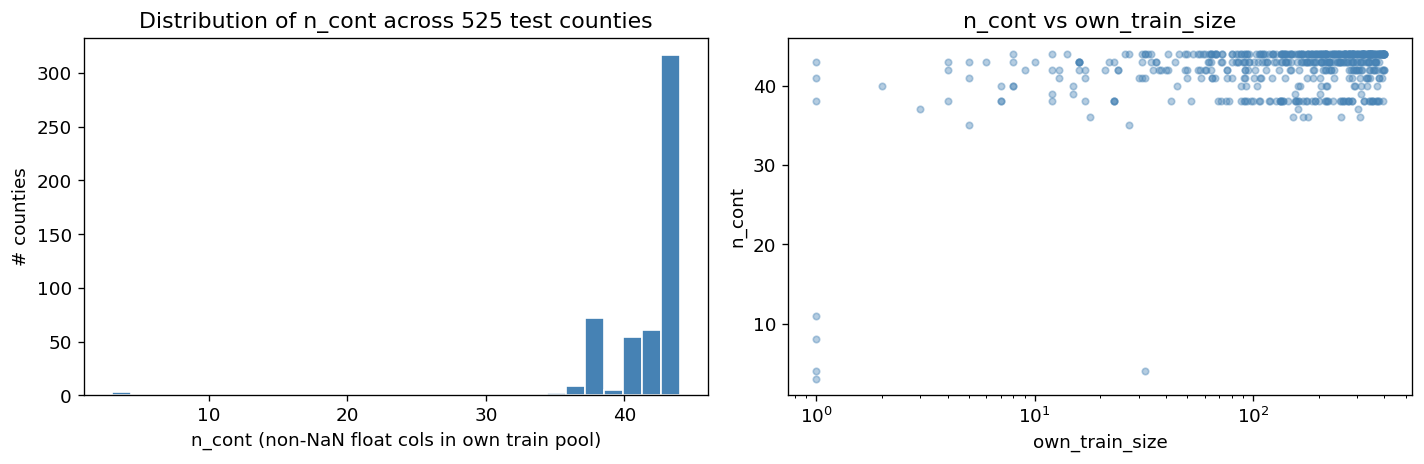

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(fips_stats["n_cont"], bins=30, color="steelblue", edgecolor="white")
axes[0].set_xlabel("n_cont (non-NaN float cols in own train pool)")
axes[0].set_ylabel("# counties")
axes[0].set_title("Distribution of n_cont across 525 test counties")

axes[1].scatter(fips_stats["own_train_size"], fips_stats["n_cont"], alpha=0.4, s=15, color="steelblue")
axes[1].set_xlabel("own_train_size")
axes[1].set_ylabel("n_cont")
axes[1].set_title("n_cont vs own_train_size")
axes[1].set_xscale("log")

plt.tight_layout()
plt.show()

## 2. Diagnostic CSV: Context Sensitivity vs n_cont

6 counties, Normal vs Shuffled-y context, for zero-shot and globally finetuned TabPFN.

In [8]:
diag = pd.read_csv(DIAG_CSV)
diag = diag.merge(fips_stats[["fips", "n_cont"]], on="fips", how="left")
print(diag.to_string(index=False))

 fips bucket  own_train_size  test_size  n_cont_x                       model     context       mape        r2           mae          rmse  n_cont_y
28115   tiny              26          7        44          TabPFN (zero-shot)      Normal  49.277428  0.309541  69030.966481  96751.737839        44
28115   tiny              26          7        44 TabPFN (globally finetuned)      Normal  59.061653 -0.754053 115520.720387 154209.545777        44
28115   tiny              26          7        44          TabPFN (zero-shot)  Shuffled-y  90.525574 -0.024830 101562.639472 117873.406531        44
28115   tiny              26          7        44 TabPFN (globally finetuned)  Shuffled-y  69.398468 -0.489516 112800.226525 142106.035534        44
28115   tiny              26          7        44          TabPFN (zero-shot) Minimal (2)   6.559944 -0.429859  22172.287786  23372.571254        44
28115   tiny              26          7        44 TabPFN (globally finetuned) Minimal (2)  10.473207 -2.77

In [13]:
diag.rename(columns={"n_cont_x":"n_cont"}, inplace=True)

In [14]:
# Wide form: one row per (fips, model), columns for each context's MAPE
diag_wide = diag[diag["context"].isin(["Normal", "Shuffled-y"])].pivot_table(
    index=["fips", "n_cont", "own_train_size", "bucket", "model"],
    columns="context",
    values="mape",
).reset_index()
diag_wide.columns.name = None
diag_wide["icl_sensitivity"] = (diag_wide["Shuffled-y"] - diag_wide["Normal"]) / diag_wide["Normal"] * 100

zs = diag_wide[diag_wide["model"] == "TabPFN (zero-shot)"].copy()
ft = diag_wide[diag_wide["model"] == "TabPFN (globally finetuned)"].copy()
diag_wide

,fips,n_cont,own_train_size,bucket,model,Normal,Shuffled-y,icl_sensitivity
0,13099,44,392,medium,TabPFN (globally finetuned),65.342832,186.852130,185.956582
1,13099,44,392,medium,TabPFN (zero-shot),73.986798,160.009025,116.266995
2,27107,40,292,medium,TabPFN (globally finetuned),30.681062,81.776443,166.537202
3,27107,40,292,medium,TabPFN (zero-shot),48.711746,84.052121,72.550008
4,28101,43,243,medium,TabPFN (globally finetuned),22.412882,64.482539,187.703021
5,28101,43,243,medium,TabPFN (zero-shot),23.026208,65.871162,186.070380
6,28115,44,26,tiny,TabPFN (globally finetuned),59.061653,69.398468,17.501738
7,28115,44,26,tiny,TabPFN (zero-shot),49.277428,90.525574,83.705963
8,48045,42,24,tiny,TabPFN (globally finetuned),34.552096,43.401052,25.610476
9,48045,42,24,tiny,TabPFN (zero-shot),28.325404,37.375795,31.951497


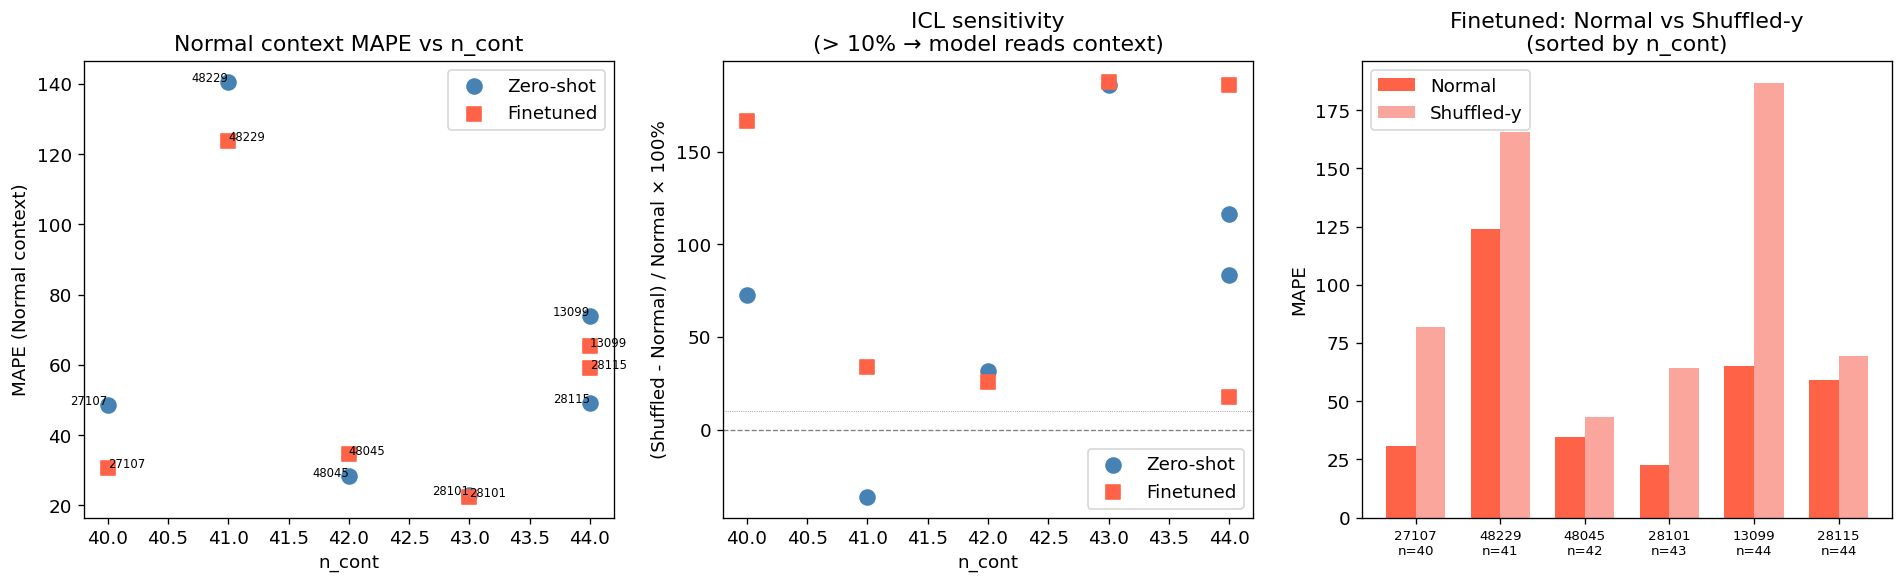

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: Normal MAPE vs n_cont
ax = axes[0]
ax.scatter(zs["n_cont"], zs["Normal"], label="Zero-shot", marker="o", s=80, color="steelblue")
ax.scatter(ft["n_cont"], ft["Normal"], label="Finetuned", marker="s", s=80, color="tomato")
for _, row in zs.iterrows():
    ax.annotate(str(row["fips"]), (row["n_cont"], row["Normal"]), fontsize=7, ha="right")
for _, row in ft.iterrows():
    ax.annotate(str(row["fips"]), (row["n_cont"], row["Normal"]), fontsize=7, ha="left")
ax.set_xlabel("n_cont")
ax.set_ylabel("MAPE (Normal context)")
ax.set_title("Normal context MAPE vs n_cont")
ax.legend()

# Panel 2: ICL sensitivity vs n_cont
ax = axes[1]
ax.scatter(zs["n_cont"], zs["icl_sensitivity"], label="Zero-shot", marker="o", s=80, color="steelblue")
ax.scatter(ft["n_cont"], ft["icl_sensitivity"], label="Finetuned", marker="s", s=80, color="tomato")
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.axhline(10, color="gray", lw=0.5, ls=":")
ax.set_xlabel("n_cont")
ax.set_ylabel("(Shuffled - Normal) / Normal × 100%")
ax.set_title("ICL sensitivity\n(> 10% → model reads context)")
ax.legend()

# Panel 3: Paired bar: Normal vs Shuffled per county for finetuned
ax = axes[2]
ft_sorted = ft.sort_values("n_cont")
x = np.arange(len(ft_sorted))
w = 0.35
ax.bar(x - w/2, ft_sorted["Normal"], w, label="Normal", color="tomato")
ax.bar(x + w/2, ft_sorted["Shuffled-y"], w, label="Shuffled-y", color="salmon", alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels([f"{row.fips}\nn={row.n_cont}" for _, row in ft_sorted.iterrows()], fontsize=8)
ax.set_ylabel("MAPE")
ax.set_title("Finetuned: Normal vs Shuffled-y\n(sorted by n_cont)")
ax.legend()

plt.tight_layout()
plt.show()

## 3. Geo-pooling Experiment Results

Load all chunks from the geo-pooling experiment, merge with fips_stats, visualize MAPE vs n_cont and own_train_size.

In [18]:
def load_geo_results(exp_dir):
    """Load all chunk results CSVs from a geo-pooling experiment directory."""
    exp_dir = Path(exp_dir)
    dfs = []
    for chunk_dir in sorted(exp_dir.glob("chunk_*/")):
        csv = chunk_dir / "results.csv"
        if csv.exists():
            dfs.append(pd.read_csv(csv))
    if not dfs:
        raise FileNotFoundError(f"No chunk results found in {exp_dir}")
    df = pd.concat(dfs, ignore_index=True)
    df["exp_dir"] = exp_dir.name
    return df

geo_dfs = []
for exp_dir in GEO_EXP_DIRS:
    geo_dfs.append(load_geo_results(exp_dir))
    print(f"  {Path(exp_dir).name}: {len(geo_dfs[-1])} rows, models={geo_dfs[-1]['model'].unique().tolist()}")

geo = pd.concat(geo_dfs, ignore_index=True)
geo = geo.merge(fips_stats[["fips", "n_cont"]], on="fips", how="left")
print(f"\nTotal: {len(geo)} rows, {geo['fips'].nunique()} unique FIPS")
print(f"n_cont matched: {geo['n_cont'].notna().sum()} / {len(geo)}")
geo.head(3)

  test_v4_geo_k40_ratio80_droplowest5_global_finetuned_internal_lr1e6: 1575 rows, models=['tabpfn', 'xgboost', 'tabpfn_global_finetuned']

Total: 1575 rows, 525 unique FIPS
n_cont matched: 1575 / 1575


,fips,size_bucket,model,own_train_size,neighbor_train_size,total_train_size,test_size,n_features,fit_time,pred_time,r2,mae,rmse,mape,mse,status,experiment_name,experiment_description,exp_dir,n_cont
0,1011,small,tabpfn,59,47,106,16,107,8.131305,1.482149,0.880389,47355.301327,60567.671291,82.044780,3.668443e+09,success,test_v4_geo_k40_ratio80_droplowest5_global_fin...,Per-county geo pooling with globally finetuned...,test_v4_geo_k40_ratio80_droplowest5_global_fin...,42
1,1011,small,xgboost,59,47,106,16,107,124.007161,0.023639,0.775765,49971.607846,82929.131779,66.464312,6.877241e+09,success,test_v4_geo_k40_ratio80_droplowest5_global_fin...,Per-county geo pooling with globally finetuned...,test_v4_geo_k40_ratio80_droplowest5_global_fin...,42
2,1011,small,tabpfn_global_finetuned,59,47,106,16,107,0.000000,0.230896,0.870766,40215.014584,62957.099337,43.325579,3.963596e+09,success,test_v4_geo_k40_ratio80_droplowest5_global_fin...,Per-county geo pooling with globally finetuned...,test_v4_geo_k40_ratio80_droplowest5_global_fin...,42


In [19]:
# Pivot to one row per FIPS: compare models side-by-side
geo_pivot = geo[geo["status"] == "success"].pivot_table(
    index=["fips", "n_cont", "own_train_size", "size_bucket", "exp_dir"],
    columns="model",
    values="mape",
).reset_index()
geo_pivot.columns.name = None

# Ratio: finetuned / zero-shot
if "tabpfn_global_finetuned" in geo_pivot.columns and "tabpfn" in geo_pivot.columns:
    geo_pivot["ft_vs_zs_ratio"] = geo_pivot["tabpfn_global_finetuned"] / geo_pivot["tabpfn"]

print(geo_pivot.shape)
geo_pivot.head()

(518, 9)


,fips,n_cont,own_train_size,size_bucket,exp_dir,tabpfn,tabpfn_global_finetuned,xgboost,ft_vs_zs_ratio
0,1011,42,59,small,test_v4_geo_k40_ratio80_droplowest5_global_fin...,82.044780,43.325579,66.464312,0.528072
1,1013,43,351,medium,test_v4_geo_k40_ratio80_droplowest5_global_fin...,30.081216,29.771961,30.093128,0.989719
2,1025,42,194,medium,test_v4_geo_k40_ratio80_droplowest5_global_fin...,45.945093,35.742857,45.334635,0.777947
3,1029,42,190,medium,test_v4_geo_k40_ratio80_droplowest5_global_fin...,39.987434,40.232833,41.307749,1.006137
4,1037,43,327,medium,test_v4_geo_k40_ratio80_droplowest5_global_fin...,45.560422,45.106900,48.049968,0.990046


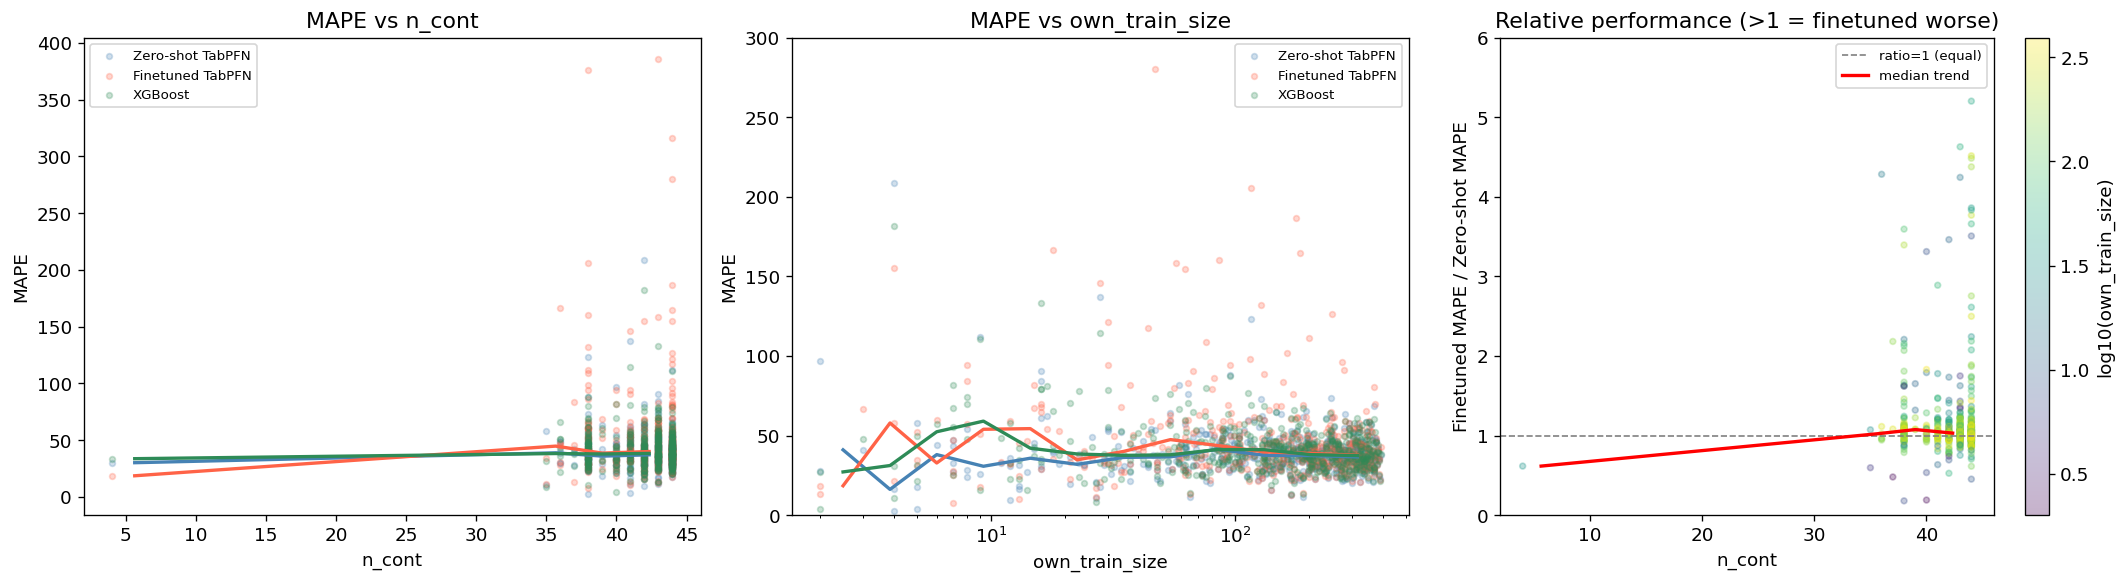

In [20]:
models_present = [m for m in ["tabpfn", "tabpfn_global_finetuned", "xgboost"] if m in geo_pivot.columns]
colors = {"tabpfn": "steelblue", "tabpfn_global_finetuned": "tomato", "xgboost": "seagreen"}
labels = {"tabpfn": "Zero-shot TabPFN", "tabpfn_global_finetuned": "Finetuned TabPFN", "xgboost": "XGBoost"}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: MAPE vs n_cont
ax = axes[0]
for m in models_present:
    ax.scatter(geo_pivot["n_cont"], geo_pivot[m], alpha=0.25, s=12, color=colors[m], label=labels[m])
# Add smoothed trend (binned mean)
for m in models_present:
    tmp = geo_pivot[["n_cont", m]].dropna()
    tmp["bin"] = pd.cut(tmp["n_cont"], bins=12)
    trend = tmp.groupby("bin", observed=True)[m].median().reset_index()
    midpoints = trend["bin"].apply(lambda x: x.mid)
    ax.plot(midpoints, trend[m], color=colors[m], lw=2)
ax.set_xlabel("n_cont")
ax.set_ylabel("MAPE")
ax.set_title("MAPE vs n_cont")
# ax.set_ylim(0, 300)
ax.legend(fontsize=8)

# Panel 2: MAPE vs own_train_size
ax = axes[1]
for m in models_present:
    ax.scatter(geo_pivot["own_train_size"], geo_pivot[m], alpha=0.25, s=12, color=colors[m], label=labels[m])
for m in models_present:
    tmp = geo_pivot[["own_train_size", m]].dropna()
    tmp["bin"] = pd.cut(np.log10(tmp["own_train_size"].clip(lower=1)), bins=12)
    trend = tmp.groupby("bin", observed=True)[m].median().reset_index()
    midpoints = trend["bin"].apply(lambda x: 10 ** x.mid)
    ax.plot(midpoints, trend[m], color=colors[m], lw=2)
ax.set_xlabel("own_train_size")
ax.set_ylabel("MAPE")
ax.set_title("MAPE vs own_train_size")
ax.set_xscale("log")
ax.set_ylim(0, 300)
ax.legend(fontsize=8)

# Panel 3: Finetuned / ZeroShot ratio vs n_cont
ax = axes[2]
if "ft_vs_zs_ratio" in geo_pivot.columns:
    valid = geo_pivot.dropna(subset=["ft_vs_zs_ratio", "n_cont"])
    sc = ax.scatter(valid["n_cont"], valid["ft_vs_zs_ratio"], alpha=0.3, s=12,
                    c=np.log10(valid["own_train_size"].clip(lower=1)),
                    cmap="viridis")
    plt.colorbar(sc, ax=ax, label="log10(own_train_size)")
    ax.axhline(1.0, color="gray", lw=1, ls="--", label="ratio=1 (equal)")
    tmp = valid[["n_cont", "ft_vs_zs_ratio"]].copy()
    tmp["bin"] = pd.cut(tmp["n_cont"], bins=12)
    trend = tmp.groupby("bin", observed=True)["ft_vs_zs_ratio"].median().reset_index()
    midpoints = trend["bin"].apply(lambda x: x.mid)
    ax.plot(midpoints, trend["ft_vs_zs_ratio"], color="red", lw=2, label="median trend")
    ax.set_ylim(0, 6)
    ax.set_xlabel("n_cont")
    ax.set_ylabel("Finetuned MAPE / Zero-shot MAPE")
    ax.set_title("Relative performance (>1 = finetuned worse)")
    ax.legend(fontsize=8)
else:
    ax.text(0.5, 0.5, "tabpfn or tabpfn_global_finetuned\nnot found in results",
            ha="center", va="center", transform=ax.transAxes)

plt.tight_layout()
plt.show()

In [21]:
# Binned summary: median MAPE by n_cont decile
geo_pivot["n_cont_bin"] = pd.qcut(geo_pivot["n_cont"], q=5, duplicates="drop")
summary = geo_pivot.groupby("n_cont_bin", observed=True)[models_present].median().round(1)
if "ft_vs_zs_ratio" in geo_pivot.columns:
    summary["ft_vs_zs_ratio"] = geo_pivot.groupby("n_cont_bin", observed=True)["ft_vs_zs_ratio"].median().round(2)
summary["count"] = geo_pivot.groupby("n_cont_bin", observed=True)["fips"].count()
print("Median MAPE by n_cont quintile:")
summary

Median MAPE by n_cont quintile:


,tabpfn,tabpfn_global_finetuned,xgboost,ft_vs_zs_ratio,count
n_cont_bin,,,,,
"(3.999, 40.0]",36.7,38.6,37.8,1.07,107
"(40.0, 43.0]",37.1,39.9,39.4,1.03,199
"(43.0, 44.0]",37.0,40.1,37.9,1.03,212


## 4. Compare multiple geo-pooling experiments

Add more paths to `GEO_EXP_DIRS` at the top and re-run from Section 3 to compare experiments side-by-side.

In [ ]:
# Example: compare across random seeds
# Uncomment and edit GEO_EXP_DIRS above to include multiple seeds, then run:

# if geo["exp_dir"].nunique() > 1:
#     fig, ax = plt.subplots(figsize=(10, 5))
#     for exp_name, grp in geo[geo["model"] == "tabpfn_global_finetuned"].groupby("exp_dir"):
#         merged = grp.merge(fips_stats[["fips", "n_cont"]], on="fips", how="left")
#         merged["bin"] = pd.cut(merged["n_cont"], bins=10)
#         trend = merged.groupby("bin", observed=True)["mape"].median()
#         midpoints = [b.mid for b in trend.index]
#         ax.plot(midpoints, trend.values, label=exp_name)
#     ax.set_xlabel("n_cont")
#     ax.set_ylabel("Median MAPE (finetuned)")
#     ax.legend(fontsize=7)
#     plt.show()
print("Edit GEO_EXP_DIRS at the top to compare multiple experiments.")

## 5. Prediction Distribution Comparison: Zero-shot vs Finetuned

Load per-sample predictions from the geo-pooling experiment (which runs both `tabpfn` and `tabpfn_global_finetuned` on the same test data). Compare prediction distributions, residuals, bias, and spread to understand *how* the finetuned model fails — not just that it's worse.

In [22]:
# Load per-sample predictions from all chunks of the finetuned geo-pooling experiment
FT_EXP_DIR = Path(GEO_EXP_DIRS[0])

pred_dfs = []
for chunk_dir in sorted(FT_EXP_DIR.glob("chunk_*/")):
    pred_path = chunk_dir / "predictions.parquet"
    if pred_path.exists():
        pred_dfs.append(pd.read_parquet(pred_path, columns=["fips", "model", "y_true", "y_pred"]))
preds = pd.concat(pred_dfs, ignore_index=True)
print(f"Loaded {len(preds):,} prediction rows from {FT_EXP_DIR.name}")
print(f"Models: {preds['model'].value_counts().to_dict()}")
print(f"Counties: {preds['fips'].nunique()}")

# Add within-(fips, model) row index so we can match the same test sample across models
preds["row_idx"] = preds.groupby(["fips", "model"]).cumcount()

# Pivot to one row per test sample with columns for each model's prediction
zs_preds = preds[preds["model"] == "tabpfn"][["fips", "row_idx", "y_true", "y_pred"]].rename(
    columns={"y_pred": "pred_zs"})
ft_preds = preds[preds["model"] == "tabpfn_global_finetuned"][["fips", "row_idx", "y_pred"]].rename(
    columns={"y_pred": "pred_ft"})
xgb_preds = preds[preds["model"] == "xgboost"][["fips", "row_idx", "y_pred"]].rename(
    columns={"y_pred": "pred_xgb"})

matched = (
    zs_preds
    .merge(ft_preds, on=["fips", "row_idx"], how="inner")
    .merge(xgb_preds, on=["fips", "row_idx"], how="inner")
)

# Residuals (log-space) and per-sample absolute percentage error (original scale)
for tag in ["zs", "ft", "xgb"]:
    matched[f"resid_{tag}"] = matched[f"pred_{tag}"] - matched["y_true"]
    matched[f"ape_{tag}"] = np.abs(np.exp(matched[f"resid_{tag}"]) - 1) * 100

print(f"\nMatched {len(matched):,} test samples across {matched['fips'].nunique()} counties")
matched.head(3)

Loaded 72,258 prediction rows from test_v4_geo_k40_ratio80_droplowest5_global_finetuned_internal_lr1e6
Models: {'tabpfn': 24086, 'xgboost': 24086, 'tabpfn_global_finetuned': 24086}
Counties: 518

Matched 24,086 test samples across 518 counties


,fips,row_idx,y_true,pred_zs,pred_ft,pred_xgb,resid_zs,ape_zs,resid_ft,ape_ft,resid_xgb,ape_xgb
0,1011,0,9.010305,10.608293,9.888830,10.064233,1.597988,394.307564,0.878525,140.734707,1.053928,186.889800
1,1011,1,11.813030,11.820483,11.874581,11.812176,0.007453,0.748099,0.061551,6.348503,-0.000854,0.085394
2,1011,2,11.127263,11.744791,11.474689,11.519208,0.617528,85.433853,0.347426,41.542027,0.391945,47.985627


In [23]:
# Per-county summary statistics from matched predictions
county_pred_stats = matched.groupby('fips').agg(
    n_test=('y_true', 'count'),
    y_true_mean=('y_true', 'mean'),
    y_true_std=('y_true', 'std'),
    # Prediction means — offset from y_true_mean indicates bias
    pred_zs_mean=('pred_zs', 'mean'),
    pred_ft_mean=('pred_ft', 'mean'),
    # Prediction spread — low spread indicates collapse toward a constant
    pred_zs_std=('pred_zs', 'std'),
    pred_ft_std=('pred_ft', 'std'),
    # Mean residual = bias (positive → overpredicts)
    bias_zs=('resid_zs', 'mean'),
    bias_ft=('resid_ft', 'mean'),
    # MAPE
    mape_zs=('ape_zs', 'mean'),
    mape_ft=('ape_ft', 'mean'),
    mape_xgb=('ape_xgb', 'mean'),
).reset_index()

# Derived metrics
county_pred_stats['pred_std_ratio'] = county_pred_stats['pred_ft_std'] / county_pred_stats['pred_zs_std']
county_pred_stats['bias_diff'] = county_pred_stats['bias_ft'] - county_pred_stats['bias_zs']
county_pred_stats['mape_ratio'] = county_pred_stats['mape_ft'] / county_pred_stats['mape_zs']

# Merge with n_cont / own_train_size from earlier
county_pred_stats = county_pred_stats.merge(fips_stats[['fips', 'n_cont', 'own_train_size']], on='fips', how='left')

print(f'Per-county stats: {len(county_pred_stats)} counties')
print(f'\nMedian MAPE ratio (ft/zs): {county_pred_stats["mape_ratio"].median():.3f}')
print(f'Mean bias (zs): {county_pred_stats["bias_zs"].mean():.4f}')
print(f'Mean bias (ft): {county_pred_stats["bias_ft"].mean():.4f}')
print(f'Median pred_std_ratio (ft/zs): {county_pred_stats["pred_std_ratio"].median():.3f}')
county_pred_stats.describe().round(3)

Per-county stats: 518 counties

Median MAPE ratio (ft/zs): 1.038
Mean bias (zs): -0.0296
Mean bias (ft): -0.0434
Median pred_std_ratio (ft/zs): 1.017


,fips,n_test,y_true_mean,y_true_std,pred_zs_mean,pred_ft_mean,pred_zs_std,pred_ft_std,bias_zs,bias_ft,mape_zs,mape_ft,mape_xgb,pred_std_ratio,bias_diff,mape_ratio,n_cont,own_train_size
count,518.000,518.000,518.000,513.000,518.000,518.000,513.000,513.000,518.000,518.000,518.000,518.000,518.000,513.000,518.000,518.000,518.000,518.000
mean,31703.757,46.498,11.693,0.736,11.663,11.650,0.594,0.561,-0.030,-0.043,39.191,46.900,40.877,0.975,-0.014,1.272,42.104,192.618
std,15238.320,28.073,0.583,0.194,0.612,0.606,0.211,0.248,0.172,0.246,15.251,35.010,14.997,0.451,0.196,1.274,2.806,116.856
min,1011.000,1.000,9.587,0.074,9.429,9.993,0.002,0.007,-0.927,-1.110,2.940,7.859,4.107,0.011,-0.921,0.182,4.000,2.000
25%,21057.000,22.000,11.369,0.615,11.314,11.290,0.460,0.447,-0.122,-0.143,31.213,32.472,32.433,0.955,-0.050,0.977,41.000,91.250
50%,31062.000,46.000,11.639,0.718,11.589,11.569,0.579,0.569,-0.023,-0.027,37.060,39.860,38.209,1.017,-0.010,1.038,43.000,190.000
75%,48099.000,71.000,11.979,0.858,11.964,11.947,0.711,0.712,0.060,0.068,44.045,49.840,46.439,1.063,0.032,1.129,44.000,289.750
max,56039.000,99.000,15.658,1.450,15.847,15.754,2.137,1.430,1.127,1.475,208.669,385.535,181.988,6.750,1.441,19.722,44.000,398.000


In [24]:
# Select 6 representative counties for detailed comparison
# 2 where finetuned does best (ratio < 1), 2 median, 2 where finetuned does worst
cps = county_pred_stats.dropna(subset=['mape_ratio']).copy()
cps = cps[cps['n_test'] >= 10].sort_values('mape_ratio')  # need enough test points

n_show = 2
best_ft = cps.head(n_show)
worst_ft = cps.tail(n_show)
mid_idx = len(cps) // 2
median_ft = cps.iloc[mid_idx - 1 : mid_idx + 1]

showcase = pd.concat([best_ft, median_ft, worst_ft]).reset_index(drop=True)
print('Selected counties for detailed comparison:')
print(showcase[['fips', 'n_cont', 'own_train_size', 'n_test',
                'mape_zs', 'mape_ft', 'mape_xgb', 'mape_ratio']].to_string(index=False))

Selected counties for detailed comparison:
 fips  n_cont  own_train_size  n_test   mape_zs    mape_ft  mape_xgb  mape_ratio
 1011      42              61      16 82.044785  43.325580 66.464312    0.528072
 8025      44             141      34 55.475938  34.182035 36.096011    0.616160
21039      44             237      53 38.614368  39.916525 37.357991    1.033722
51091      42             280      63 40.580969  41.956006 45.667273    1.033884
31171      44              64      14 53.819078 279.969255 73.517133    5.202045
31149      44             118      31 37.512170 316.390279 39.821511    8.434337


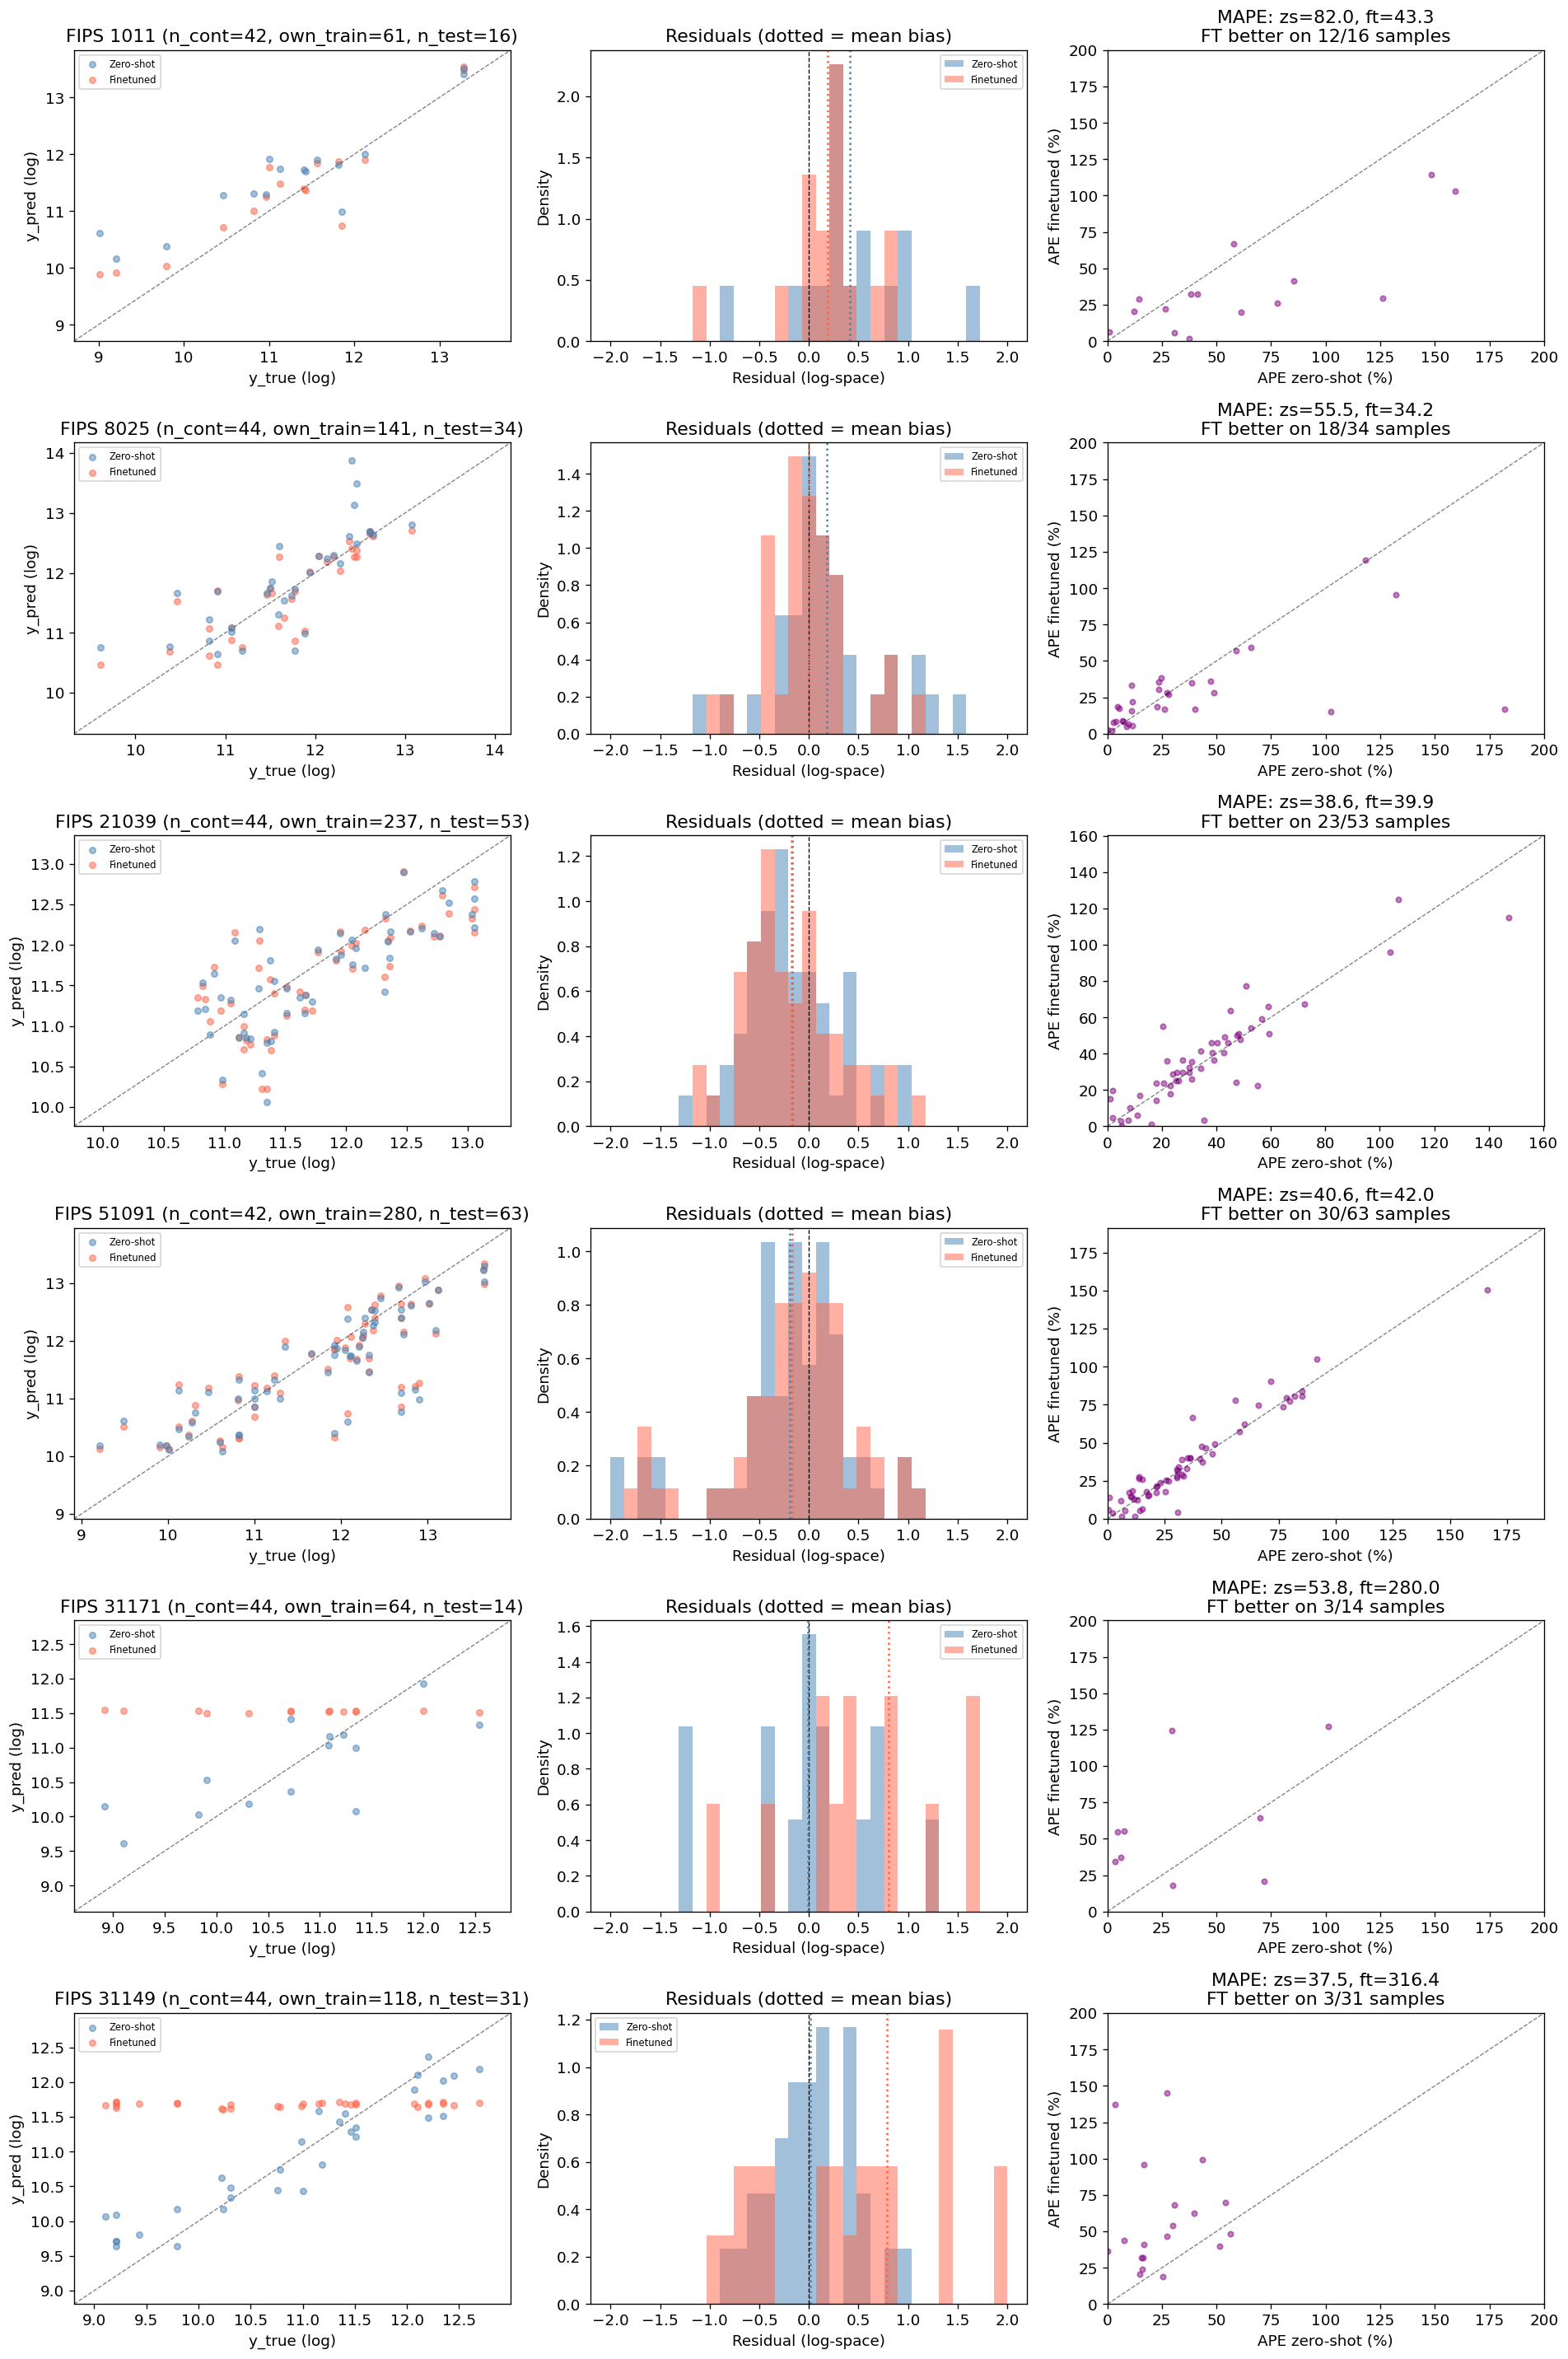

In [25]:
# Per-county panels: scatter y_pred vs y_true, residual histogram, per-sample APE comparison
fig, axes = plt.subplots(len(showcase), 3, figsize=(16, 4 * len(showcase)))
if len(showcase) == 1:
    axes = axes.reshape(1, -1)

for i, (_, row) in enumerate(showcase.iterrows()):
    fips_i = row['fips']
    county = matched[matched['fips'] == fips_i]
    y_true_i = county['y_true'].values
    y_zs = county['pred_zs'].values
    y_ft = county['pred_ft'].values

    # Panel 1: Scatter y_pred vs y_true (log-space)
    ax = axes[i, 0]
    lo = min(y_true_i.min(), y_zs.min(), y_ft.min()) - 0.3
    hi = max(y_true_i.max(), y_zs.max(), y_ft.max()) + 0.3
    ax.scatter(y_true_i, y_zs, alpha=0.5, s=20, color='steelblue', label='Zero-shot', zorder=3)
    ax.scatter(y_true_i, y_ft, alpha=0.5, s=20, color='tomato', label='Finetuned', zorder=2)
    ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8, alpha=0.5)
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_xlabel('y_true (log)'); ax.set_ylabel('y_pred (log)')
    ax.set_title(f'FIPS {int(fips_i)} (n_cont={int(row["n_cont"])}, '
                 f'own_train={int(row["own_train_size"])}, n_test={int(row["n_test"])})')
    ax.legend(fontsize=7)

    # Panel 2: Residual histograms (log-space)
    ax = axes[i, 1]
    bins = np.linspace(-2, 2, 30)
    ax.hist(county['resid_zs'], bins=bins, alpha=0.5, color='steelblue', label='Zero-shot', density=True)
    ax.hist(county['resid_ft'], bins=bins, alpha=0.5, color='tomato', label='Finetuned', density=True)
    ax.axvline(0, color='k', lw=0.8, ls='--')
    ax.axvline(county['resid_zs'].mean(), color='steelblue', lw=1.5, ls=':')
    ax.axvline(county['resid_ft'].mean(), color='tomato', lw=1.5, ls=':')
    ax.set_xlabel('Residual (log-space)'); ax.set_ylabel('Density')
    ax.set_title(f'Residuals (dotted = mean bias)')
    ax.legend(fontsize=7)

    # Panel 3: Per-sample APE scatter (finetuned vs zero-shot)
    ax = axes[i, 2]
    max_ape = min(200, max(county['ape_zs'].quantile(0.98), county['ape_ft'].quantile(0.98)) * 1.1)
    ax.scatter(county['ape_zs'], county['ape_ft'], alpha=0.5, s=15, color='purple')
    ax.plot([0, max_ape], [0, max_ape], 'k--', lw=0.8, alpha=0.5)
    ax.set_xlim(0, max_ape); ax.set_ylim(0, max_ape)
    ax.set_xlabel('APE zero-shot (%)')
    ax.set_ylabel('APE finetuned (%)')
    n_ft_wins = (county['ape_ft'] < county['ape_zs']).sum()
    ax.set_title(f'MAPE: zs={row["mape_zs"]:.1f}, ft={row["mape_ft"]:.1f}\n'
                 f'FT better on {n_ft_wins}/{len(county)} samples')

plt.tight_layout()
plt.show()

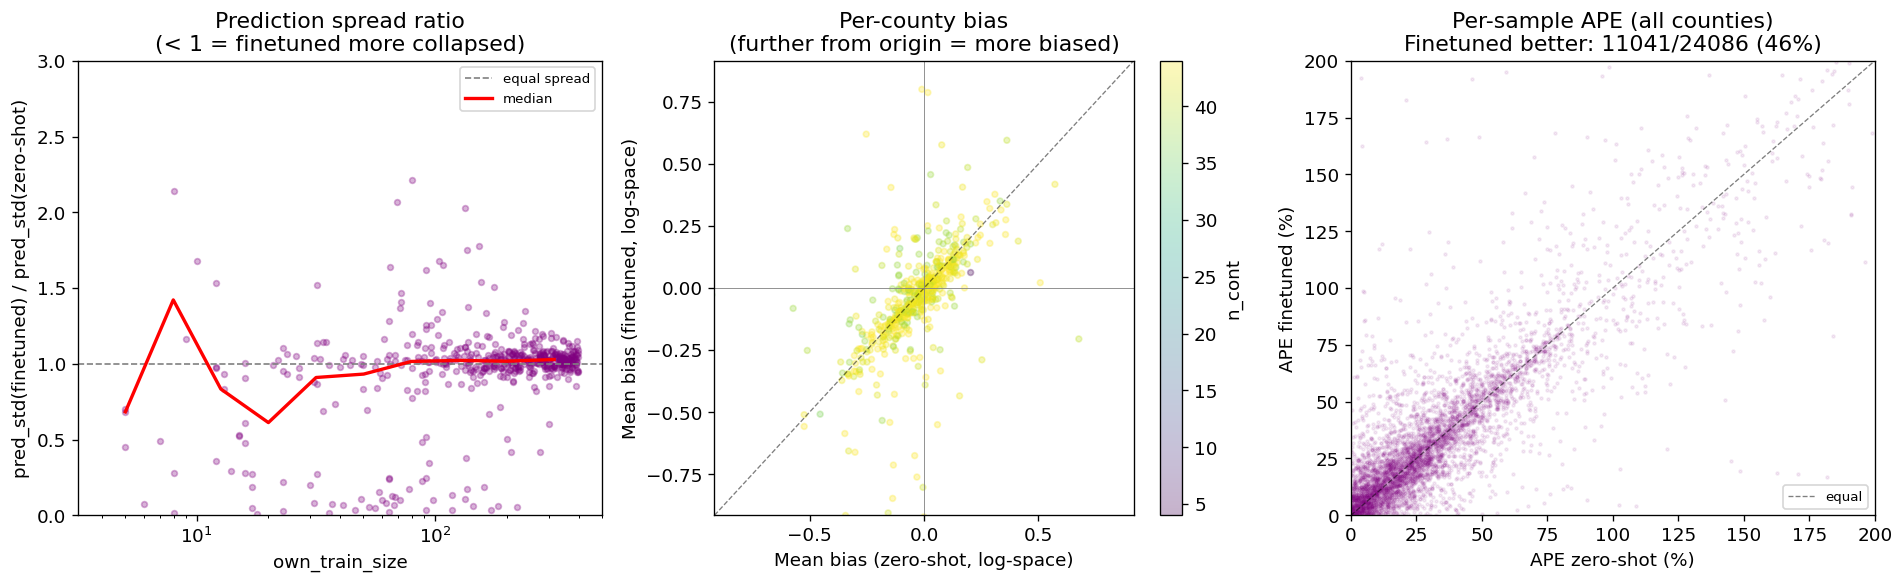

In [26]:
# Aggregate analysis: prediction spread, bias, and per-sample APE
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: Prediction std ratio — is finetuned collapsing?
ax = axes[0]
valid = county_pred_stats.dropna(subset=['pred_std_ratio', 'n_cont'])
ax.scatter(valid['own_train_size'], valid['pred_std_ratio'], alpha=0.3, s=12, color='purple')
ax.axhline(1, color='gray', lw=1, ls='--', label='equal spread')
ax.set_xlabel('own_train_size')
ax.set_ylabel('pred_std(finetuned) / pred_std(zero-shot)')
ax.set_title('Prediction spread ratio\n(< 1 = finetuned more collapsed)')
ax.set_xscale('log')
ax.set_ylim(0, 3)
# Binned trend
tmp = valid.copy()
tmp['bin'] = pd.cut(np.log10(tmp['own_train_size'].clip(lower=1)), bins=10)
trend = tmp.groupby('bin', observed=True)['pred_std_ratio'].median()
midpoints = [10 ** b.mid for b in trend.index]
ax.plot(midpoints, trend.values, color='red', lw=2, label='median')
ax.legend(fontsize=8)

# Panel 2: Bias comparison
ax = axes[1]
sc = ax.scatter(county_pred_stats['bias_zs'], county_pred_stats['bias_ft'],
                alpha=0.3, s=12, c=county_pred_stats['n_cont'], cmap='viridis')
lim = min(2.0, max(abs(county_pred_stats['bias_zs']).quantile(0.98),
                   abs(county_pred_stats['bias_ft']).quantile(0.98)) * 1.1)
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.plot([-lim, lim], [-lim, lim], 'k--', lw=0.8, alpha=0.5)
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_xlabel('Mean bias (zero-shot, log-space)')
ax.set_ylabel('Mean bias (finetuned, log-space)')
ax.set_title('Per-county bias\n(further from origin = more biased)')
plt.colorbar(sc, ax=ax, label='n_cont')

# Panel 3: Per-sample APE scatter across ALL samples
ax = axes[2]
sample = matched.sample(min(5000, len(matched)), random_state=42)
ax.scatter(sample['ape_zs'], sample['ape_ft'], alpha=0.08, s=3, color='purple')
ax.plot([0, 200], [0, 200], 'k--', lw=0.8, alpha=0.5, label='equal')
ax.set_xlim(0, 200); ax.set_ylim(0, 200)
ax.set_xlabel('APE zero-shot (%)')
ax.set_ylabel('APE finetuned (%)')
n_ft_better = (matched['ape_ft'] < matched['ape_zs']).sum()
n_total = len(matched)
ax.set_title(f'Per-sample APE (all counties)\n'
             f'Finetuned better: {n_ft_better}/{n_total} ({100*n_ft_better/n_total:.0f}%)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [27]:
# Summary statistics
print('=' * 70)
print('AGGREGATE SUMMARY: Finetuned vs Zero-shot')
print('=' * 70)

cps = county_pred_stats

print(f'\nCounties analyzed: {len(cps)}')

print(f'\nMAPE (median across counties):')
print(f'  Zero-shot:  {cps["mape_zs"].median():.1f}')
print(f'  Finetuned:  {cps["mape_ft"].median():.1f}')
print(f'  XGBoost:    {cps["mape_xgb"].median():.1f}')

print(f'\nMAPE ratio (ft/zs):')
print(f'  Median: {cps["mape_ratio"].median():.3f}')
print(f'  Counties where finetuned better (ratio < 1): {(cps["mape_ratio"] < 1).sum()}')
print(f'  Counties where finetuned worse  (ratio > 1): {(cps["mape_ratio"] > 1).sum()}')

print(f'\nBias (mean log-space residual, averaged across counties):')
print(f'  Zero-shot:  {cps["bias_zs"].mean():.4f} (positive = overpredicts)')
print(f'  Finetuned:  {cps["bias_ft"].mean():.4f}')

print(f'\nPrediction spread (pred_std, median across counties):')
print(f'  Zero-shot:  {cps["pred_zs_std"].median():.4f}')
print(f'  Finetuned:  {cps["pred_ft_std"].median():.4f}')
print(f'  Ratio:      {cps["pred_std_ratio"].median():.3f}')

print(f'\nPer-sample breakdown ({len(matched)} test samples):')
n_ft_better = (matched['ape_ft'] < matched['ape_zs']).sum()
print(f'  Finetuned better: {n_ft_better} ({100*n_ft_better/len(matched):.1f}%)')
print(f'  Zero-shot better: {len(matched) - n_ft_better} ({100*(1 - n_ft_better/len(matched)):.1f}%)')

AGGREGATE SUMMARY: Finetuned vs Zero-shot

Counties analyzed: 518

MAPE (median across counties):
  Zero-shot:  37.1
  Finetuned:  39.9
  XGBoost:    38.2

MAPE ratio (ft/zs):
  Median: 1.038
  Counties where finetuned better (ratio < 1): 181
  Counties where finetuned worse  (ratio > 1): 337

Bias (mean log-space residual, averaged across counties):
  Zero-shot:  -0.0296 (positive = overpredicts)
  Finetuned:  -0.0434

Prediction spread (pred_std, median across counties):
  Zero-shot:  0.5795
  Finetuned:  0.5688
  Ratio:      1.017

Per-sample breakdown (24086 test samples):
  Finetuned better: 11041 (45.8%)
  Zero-shot better: 13045 (54.2%)


## 6. Training Curves: Global Finetuning

Check for overfitting: does train loss keep decreasing while validation performance peaks early and degrades?

Note: `val_losses` was not logged (only `val_metrics` with r2/mae/rmse). `best_epoch` is set by the early-stopping logic which tracks val r2.

In [1]:
import matplotlib.pyplot as plt

Total epochs trained: 27
Best epoch (val r2): 11
Patience setting: 16  →  training stopped at epoch 27 = 27

Train loss at epoch 11: 0.7722
Train loss at final epoch 27: 0.9036
Val r2 at epoch 11: 0.7840
Val r2 at final epoch 27: 0.7761

Key finding: train loss stalled after best_epoch, val r2 degraded → OK


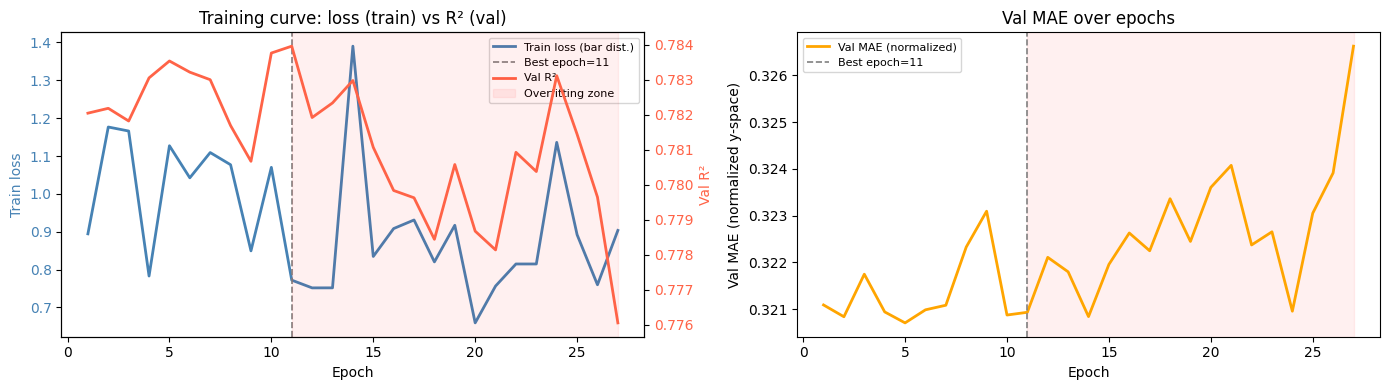

In [2]:
import json, math

CHECKPOINT_DIR = "/nlp/scr/salilg/property_tax/results/global_finetuning/v2_no_onehot/internal_15k_lr1e6_ctxdiv/"

with open(CHECKPOINT_DIR + "history.json") as f:
    hist = json.load(f)

train_losses = hist["train_losses"]
val_metrics  = hist["val_metrics"]   # list of dicts with r2/mae/rmse per epoch
best_epoch   = hist["best_epoch"]    # 1-indexed
lrs          = hist.get("learning_rates", [])

epochs = list(range(1, len(train_losses) + 1))
val_r2   = [m["r2"]  for m in val_metrics[:len(epochs)]]
val_mae  = [m["mae"] for m in val_metrics[:len(epochs)]]

print(f"Total epochs trained: {len(epochs)}")
print(f"Best epoch (val r2): {best_epoch}")
print(f"Patience setting: 16  →  training stopped at epoch {best_epoch + 16} = {len(epochs)}")
print(f"\nTrain loss at epoch {best_epoch}: {train_losses[best_epoch-1]:.4f}")
print(f"Train loss at final epoch {len(epochs)}: {train_losses[-1]:.4f}")
print(f"Val r2 at epoch {best_epoch}: {val_r2[best_epoch-1]:.4f}")
print(f"Val r2 at final epoch {len(epochs)}: {val_r2[-1]:.4f}")
print(f"\nKey finding: train loss {'kept improving' if train_losses[-1] < train_losses[best_epoch-1] else 'stalled'} "
      f"after best_epoch, val r2 {'degraded' if val_r2[-1] < val_r2[best_epoch-1] else 'held'} → "
      f"{'OVERFITTING' if train_losses[-1] < train_losses[best_epoch-1] and val_r2[-1] < val_r2[best_epoch-1] else 'OK'}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: train loss + val r2 on dual axis
ax1 = axes[0]
color_train, color_val = "steelblue", "tomato"
ax1.plot(epochs, train_losses, color=color_train, lw=2, label="Train loss (bar dist.)")
ax1.axvline(best_epoch, color="gray", lw=1.2, ls="--", label=f"Best epoch={best_epoch}")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Train loss", color=color_train)
ax1.tick_params(axis="y", labelcolor=color_train)
ax1.set_title("Training curve: loss (train) vs R² (val)")

ax2 = ax1.twinx()
ax2.plot(epochs, val_r2, color=color_val, lw=2, ls="-", label="Val R²")
ax2.set_ylabel("Val R²", color=color_val)
ax2.tick_params(axis="y", labelcolor=color_val)
# Shade overfitting zone
ax2.axvspan(best_epoch, max(epochs), alpha=0.06, color="red", label="Overfitting zone")

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc="upper right")

# Right: val MAE over epochs
ax = axes[1]
ax.plot(epochs, val_mae, color="orange", lw=2, label="Val MAE (normalized)")
ax.axvline(best_epoch, color="gray", lw=1.2, ls="--", label=f"Best epoch={best_epoch}")
ax.axvspan(best_epoch, max(epochs), alpha=0.06, color="red")
ax.set_xlabel("Epoch")
ax.set_ylabel("Val MAE (normalized y-space)")
ax.set_title("Val MAE over epochs")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 7. Per-county Weight Effect Analysis

Using the pipeline-comparison diagnostic (post-fix), decompose:
- **Pipeline gap**: (B - A) / A — same original weights, FT pipeline vs TabPFNRegressor
- **Weight effect**: (C - B) / B — finetuned weights vs original, same FT pipeline

Scatter each against county properties to find what drives the weight degradation.

In [5]:
import pandas as pd

Counties: 30

Median pipeline gap:  0.088  (8.8%)
Median weight effect: 0.183  (18.3%)
Median total effect:  0.712  (71.2%)


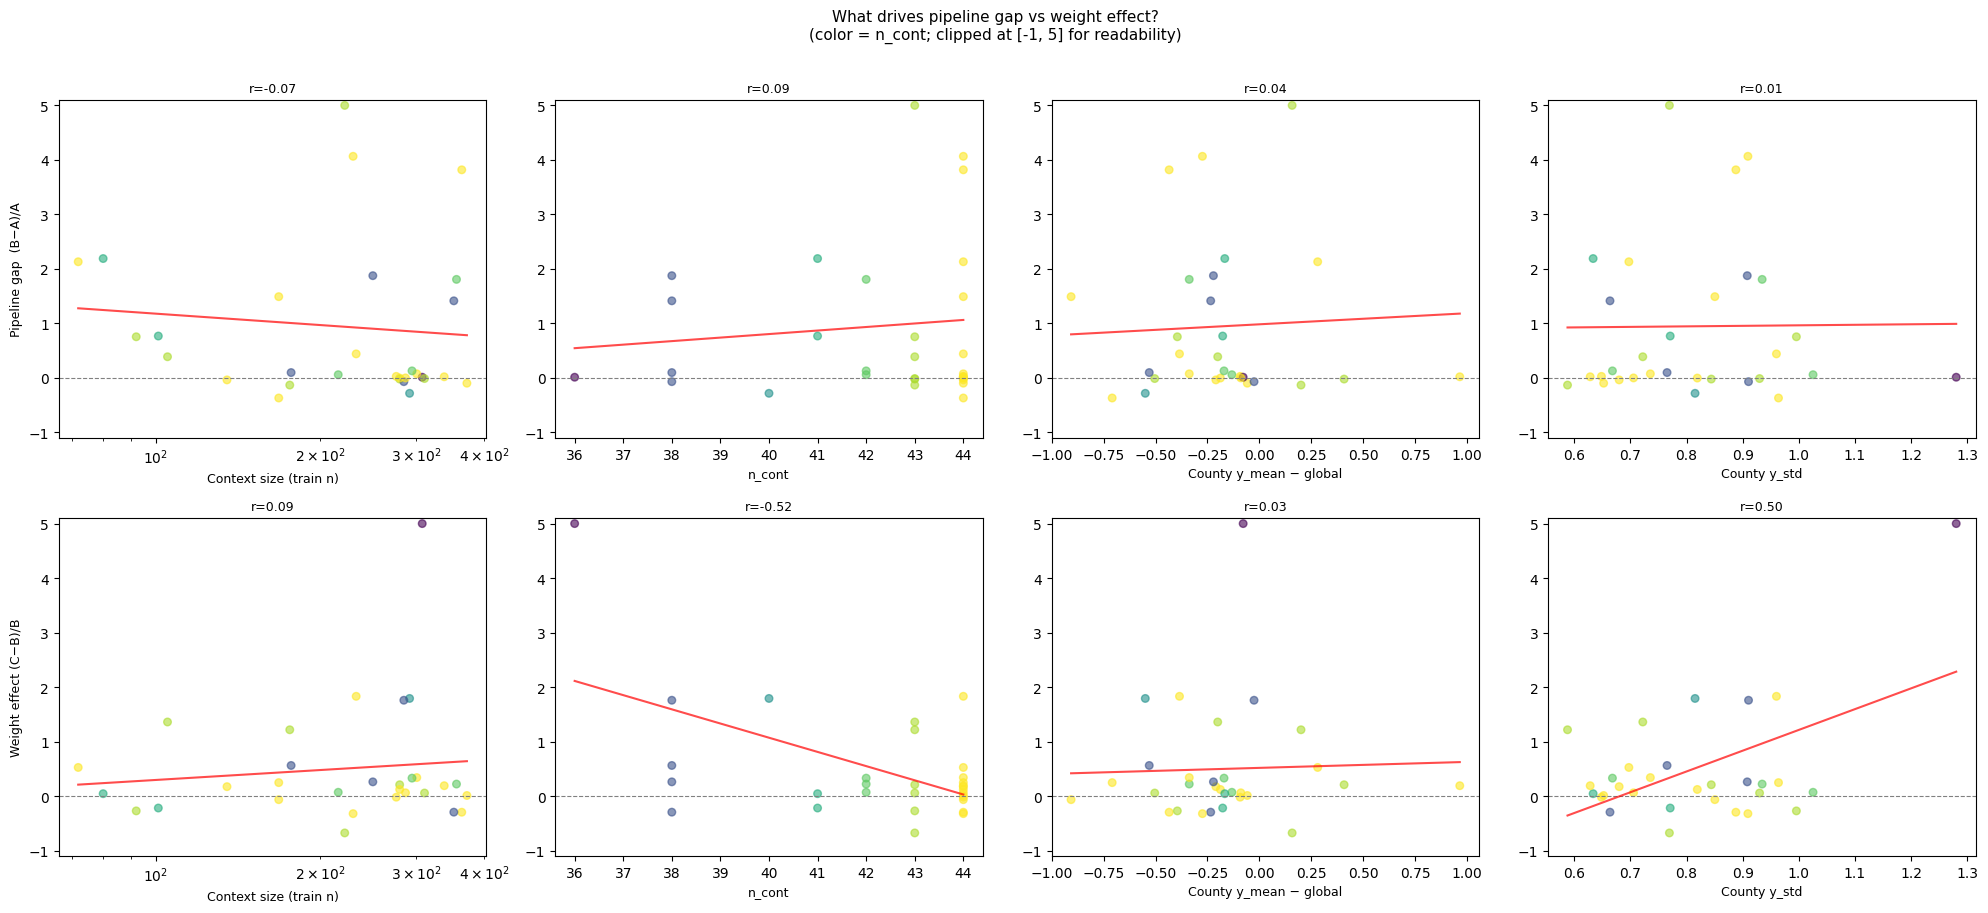


Correlation with pipeline_gap and weight_effect:
                pipeline_gap  weight_effect
own_train_size        -0.070          0.092
n_cont                 0.088         -0.523
y_mean_offset          0.041          0.033
county_y_std           0.008          0.496
pipeline_gap           1.000         -0.336
weight_effect         -0.336          1.000


In [6]:
DIAG_PIPELINE_CSV = "/sailhome/salilg/tabpfn_data_scarcity/logs/debugging/finetuning/diag_pipeline_comparison_14822951.csv"

dp = pd.read_csv(DIAG_PIPELINE_CSV)

# Pivot to wide: one row per county, one column per model's MAPE
dp_wide = dp.pivot_table(index=["fips", "n_cont", "own_train_size", "county_y_mean", "county_y_std"],
                         columns="model", values="mape").reset_index()
dp_wide.columns.name = None

# Relative effects
dp_wide["pipeline_gap"]  = (dp_wide["zs_ft_pipeline"]  - dp_wide["zs_regressor"])   / dp_wide["zs_regressor"]
dp_wide["weight_effect"] = (dp_wide["ft_pipeline"]      - dp_wide["zs_ft_pipeline"]) / dp_wide["zs_ft_pipeline"]
dp_wide["total_effect"]  = (dp_wide["ft_pipeline"]      - dp_wide["zs_regressor"])   / dp_wide["zs_regressor"]

# y_mean offset from global
GLOBAL_Y_MEAN = 11.5913
dp_wide["y_mean_offset"] = dp_wide["county_y_mean"] - GLOBAL_Y_MEAN

print(f"Counties: {len(dp_wide)}")
print(f"\nMedian pipeline gap:  {dp_wide['pipeline_gap'].median():.3f}  ({dp_wide['pipeline_gap'].median()*100:.1f}%)")
print(f"Median weight effect: {dp_wide['weight_effect'].median():.3f}  ({dp_wide['weight_effect'].median()*100:.1f}%)")
print(f"Median total effect:  {dp_wide['total_effect'].median():.3f}  ({dp_wide['total_effect'].median()*100:.1f}%)")

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
props = [
    ("own_train_size", "Context size (train n)", True),
    ("n_cont",         "n_cont",                 False),
    ("y_mean_offset",  "County y_mean − global",  False),
    ("county_y_std",   "County y_std",            False),
]

for row_i, (effect_col, effect_label) in enumerate([
    ("pipeline_gap",  "Pipeline gap  (B−A)/A"),
    ("weight_effect", "Weight effect (C−B)/B"),
]):
    for col_i, (x_col, x_label, log_x) in enumerate(props):
        ax = axes[row_i, col_i]
        valid = dp_wide.dropna(subset=[effect_col, x_col])
        # clip extreme outliers for readability
        clipped = valid[effect_col].clip(-1, 5)
        sc = ax.scatter(valid[x_col], clipped, alpha=0.6, s=30,
                        c=valid["n_cont"], cmap="viridis", vmin=36, vmax=44)
        ax.axhline(0, color="gray", lw=0.8, ls="--")
        # Pearson r
        r = valid[[x_col, effect_col]].corr().iloc[0, 1]
        ax.set_title(f"r={r:.2f}", fontsize=9)
        ax.set_xlabel(x_label, fontsize=9)
        if col_i == 0:
            ax.set_ylabel(effect_label, fontsize=9)
        if log_x:
            ax.set_xscale("log")
        ax.set_ylim(-1.1, 5.1)
        # Trend line
        import numpy as np
        x_vals = np.log10(valid[x_col]) if log_x else valid[x_col].values
        y_vals = valid[effect_col].values
        mask = np.isfinite(x_vals) & np.isfinite(y_vals)
        if mask.sum() > 3:
            z = np.polyfit(x_vals[mask], y_vals[mask], 1)
            x_fit = np.linspace(x_vals[mask].min(), x_vals[mask].max(), 100)
            ax.plot(10**x_fit if log_x else x_fit, np.polyval(z, x_fit),
                    color="red", lw=1.5, alpha=0.7)

plt.suptitle("What drives pipeline gap vs weight effect?\n(color = n_cont; clipped at [-1, 5] for readability)",
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

# Numerical summary: correlation table
print("\nCorrelation with pipeline_gap and weight_effect:")
corr_cols = ["own_train_size", "n_cont", "y_mean_offset", "county_y_std", "pipeline_gap", "weight_effect"]
print(dp_wide[corr_cols].corr()[["pipeline_gap", "weight_effect"]].round(3))